# HOuse Model

In [15]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.linear_model import LinearRegression 
import warnings
warnings.filterwarnings('ignore')

# DATA LOAD -  DATA CLean

In [16]:
df = pd.read_csv('../data/Student_Marks.csv')

In [17]:
df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [4]:
df.shape

(100, 3)

# EDA

In [28]:
col =['number_courses','time_study','Marks']

In [29]:
df_clean =df[col]

In [30]:
df_clean.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [31]:
df_clean.isna().sum()

number_courses    0
time_study        0
Marks             0
dtype: int64

number_courses , time_study , 

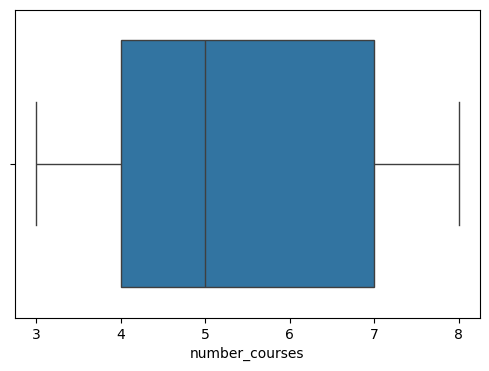

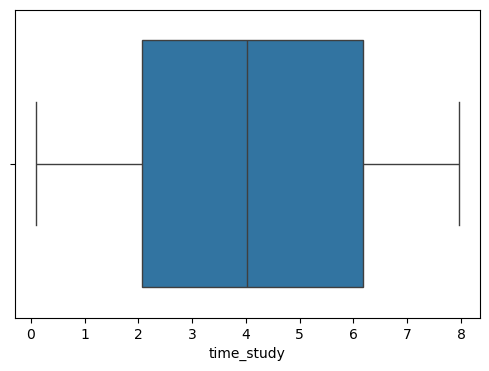

In [32]:
col =['number_courses','time_study']
for i in col:
    print(i , end = " , ")
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_clean[i])

In [33]:
df_clean.duplicated().sum()

np.int64(0)

In [34]:
df_clean.dtypes

number_courses      int64
time_study        float64
Marks             float64
dtype: object

In [35]:
df_clean.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


<Axes: >

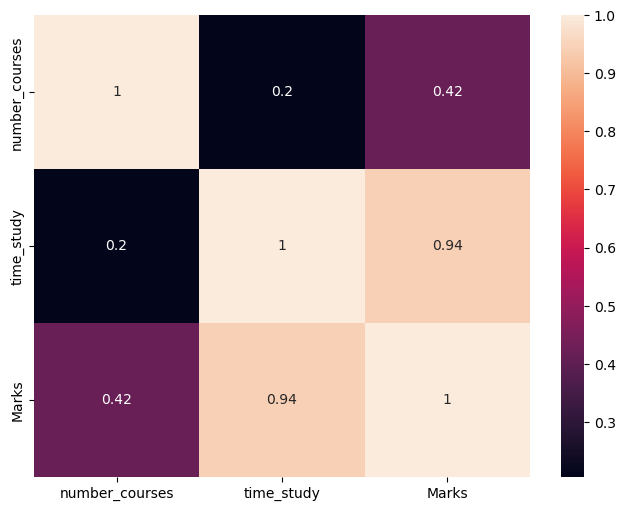

In [36]:
plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(numeric_only=True),annot=True)

# Regression Model

In [37]:
df_clean

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299
...,...,...,...
95,6,3.561,19.128
96,3,0.301,5.609
97,4,7.163,41.444
98,7,0.309,12.027


In [57]:
df_clean['result'] = df_clean['Marks'].apply(lambda x: True if x >= 30 else False)

In [58]:
df_clean

,number_courses,time_study,Marks,result
0,3,4.508,19.202,False
1,4,0.096,7.734,False
2,4,3.133,13.811,False
3,6,7.909,53.018,True
4,8,7.811,55.299,True
...,...,...,...,...
95,6,3.561,19.128,False
96,3,0.301,5.609,False
97,4,7.163,41.444,True
98,7,0.309,12.027,False


Slop  : 2
Inercept   : -7


Enter number of number of courses:  2
Enter number of study hours :  4


predicted Marks :  17.87
Result :  Fail


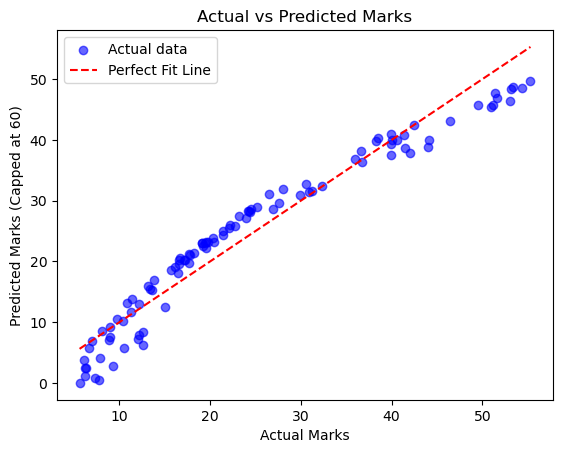

In [54]:
X=df_clean[['number_courses','time_study']]
y=df_clean["Marks"]

model=LinearRegression()
model.fit(X,y)

print("Slop  :" ,round(model.coef_[0]))
print("Inercept   :" , round(model.intercept_))

number_courses = int(input("Enter number of number of courses: "))
time_study = float(input("Enter number of study hours : "))

marks=model.predict([[number_courses , time_study]])[0]

marks = np.clip(marks, 0, 60)

result = "Pass"  if marks >=30 else  "Fail"

print(f"predicted Marks :  {marks:.2f}")
print(f"Result :  {result}")


y_pred_clipped = np.clip(model.predict(X), 0, 60)

# 3. Plotting the results
plt.scatter(y, y_pred_clipped, label="Actual data", color="blue", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Perfect Fit Line')
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks (Capped at 60)")
plt.title("Actual vs Predicted Marks")
plt.legend()
plt.show()

In [42]:
df_clean['Marks'].max()

55.299

In [43]:
df_clean['Marks'].min()

5.609

In [ ]:
# SAve the FIle

In [59]:
# Yeh aapke notebook wale folder me 'student_marks_cleaned.csv' naam se save kar dega
df_clean.to_csv('student_marks_cleaned.csv', index=False)